In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# read MWR coefficients
mwr_coeff = "../mwr_polar_coefficients.csv"
df = pd.read_csv(mwr_coeff, header=None, names=["channel", "c0", "c1", "c2"])
Tnad = df["c0"].values

print(Tnad)

[908.46972469 479.08699872 338.75165919 251.70653583 192.47340754
 141.07444985]


In [2]:


# Initialize a list to store filtered data for each channel
residu_data = [[] for _ in range(6)]
lon_data = [[] for _ in range(6)]
lat_data = [[] for _ in range(6)]


file_path = f"../20250116_PJ1to61_CH1toCH6.h5"
        
# Loop over the pj and ch values
for pj in range(51, 61):  # pj = 50 to 56 inclusive
    for ch in range(1, 7):  # ch = 1 to 6 inclusive

        # Open the HDF5 file
        with h5py.File(file_path, 'r') as h5_file:
            # Extract the data from the specified path
            data = h5_file[f'/CH{ch}/PJ{pj}/Residual'][:]+Tnad[ch-1]
            lon  = h5_file[f'/CH{ch}/PJ{pj}/longitude'][:]
            lat  = h5_file[f'/CH{ch}/PJ{pj}/latitude'][:]
            Fa   = h5_file[f'/CH{ch}/PJ{pj}/Fabiano_screeningA'][:]
            
            # Flatten the data
            data_flat = data.flatten()
            lon_flat = lon.flatten()
            lat_flat = lat.flatten()
            Fa_flat = Fa.flatten()
            
            # Filter the data: remove missing values and keep lat >= 75
            valid_indices = (~np.isnan(lon_flat)) & (~np.isnan(lat_flat)) & (lat_flat >= 73) & ((Fa_flat == 0)  | (Fa_flat == 2) )
            
            # Apply the filter
            residu_data[ch-1].extend(data_flat[valid_indices])
            lon_data[ch-1].extend(lon_flat[valid_indices])
            lat_data[ch-1].extend(lat_flat[valid_indices])

# Convert each channel list to a 1D numpy array
residu_data = [np.array(ch_data) for ch_data in residu_data]
lon_data    = [np.array(ch_data) for ch_data in lon_data]
lat_data    = [np.array(ch_data) for ch_data in lat_data]

# # Print the lengths of the filtered lon_data arrays
for i, ch_data in enumerate(zip(lon_data,lat_data,residu_data)):
    print(len(ch_data[0]))

channel_names = ["ch1","ch2", "ch3", "ch4", "ch5", "ch6"]

# Create the HDF5 file
with h5py.File("Tb_PJ51_PJ61_allchannels_FA02.h5", "w") as h5f:
    # Loop through each channel and create a group for each one
    for i, ch_name in enumerate(channel_names):
        # Create a group for each channel
        ch_group = h5f.create_group(ch_name)

        ch_group.create_dataset("Tb", data=residu_data[i])
        ch_group.create_dataset("lon", data=lon_data[i])
        ch_group.create_dataset("lat", data=lat_data[i])

8824
9778
10605
11250
11542
11707


/tmp/ipykernel_3571086/2191368095.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('RdBu_r', 255)


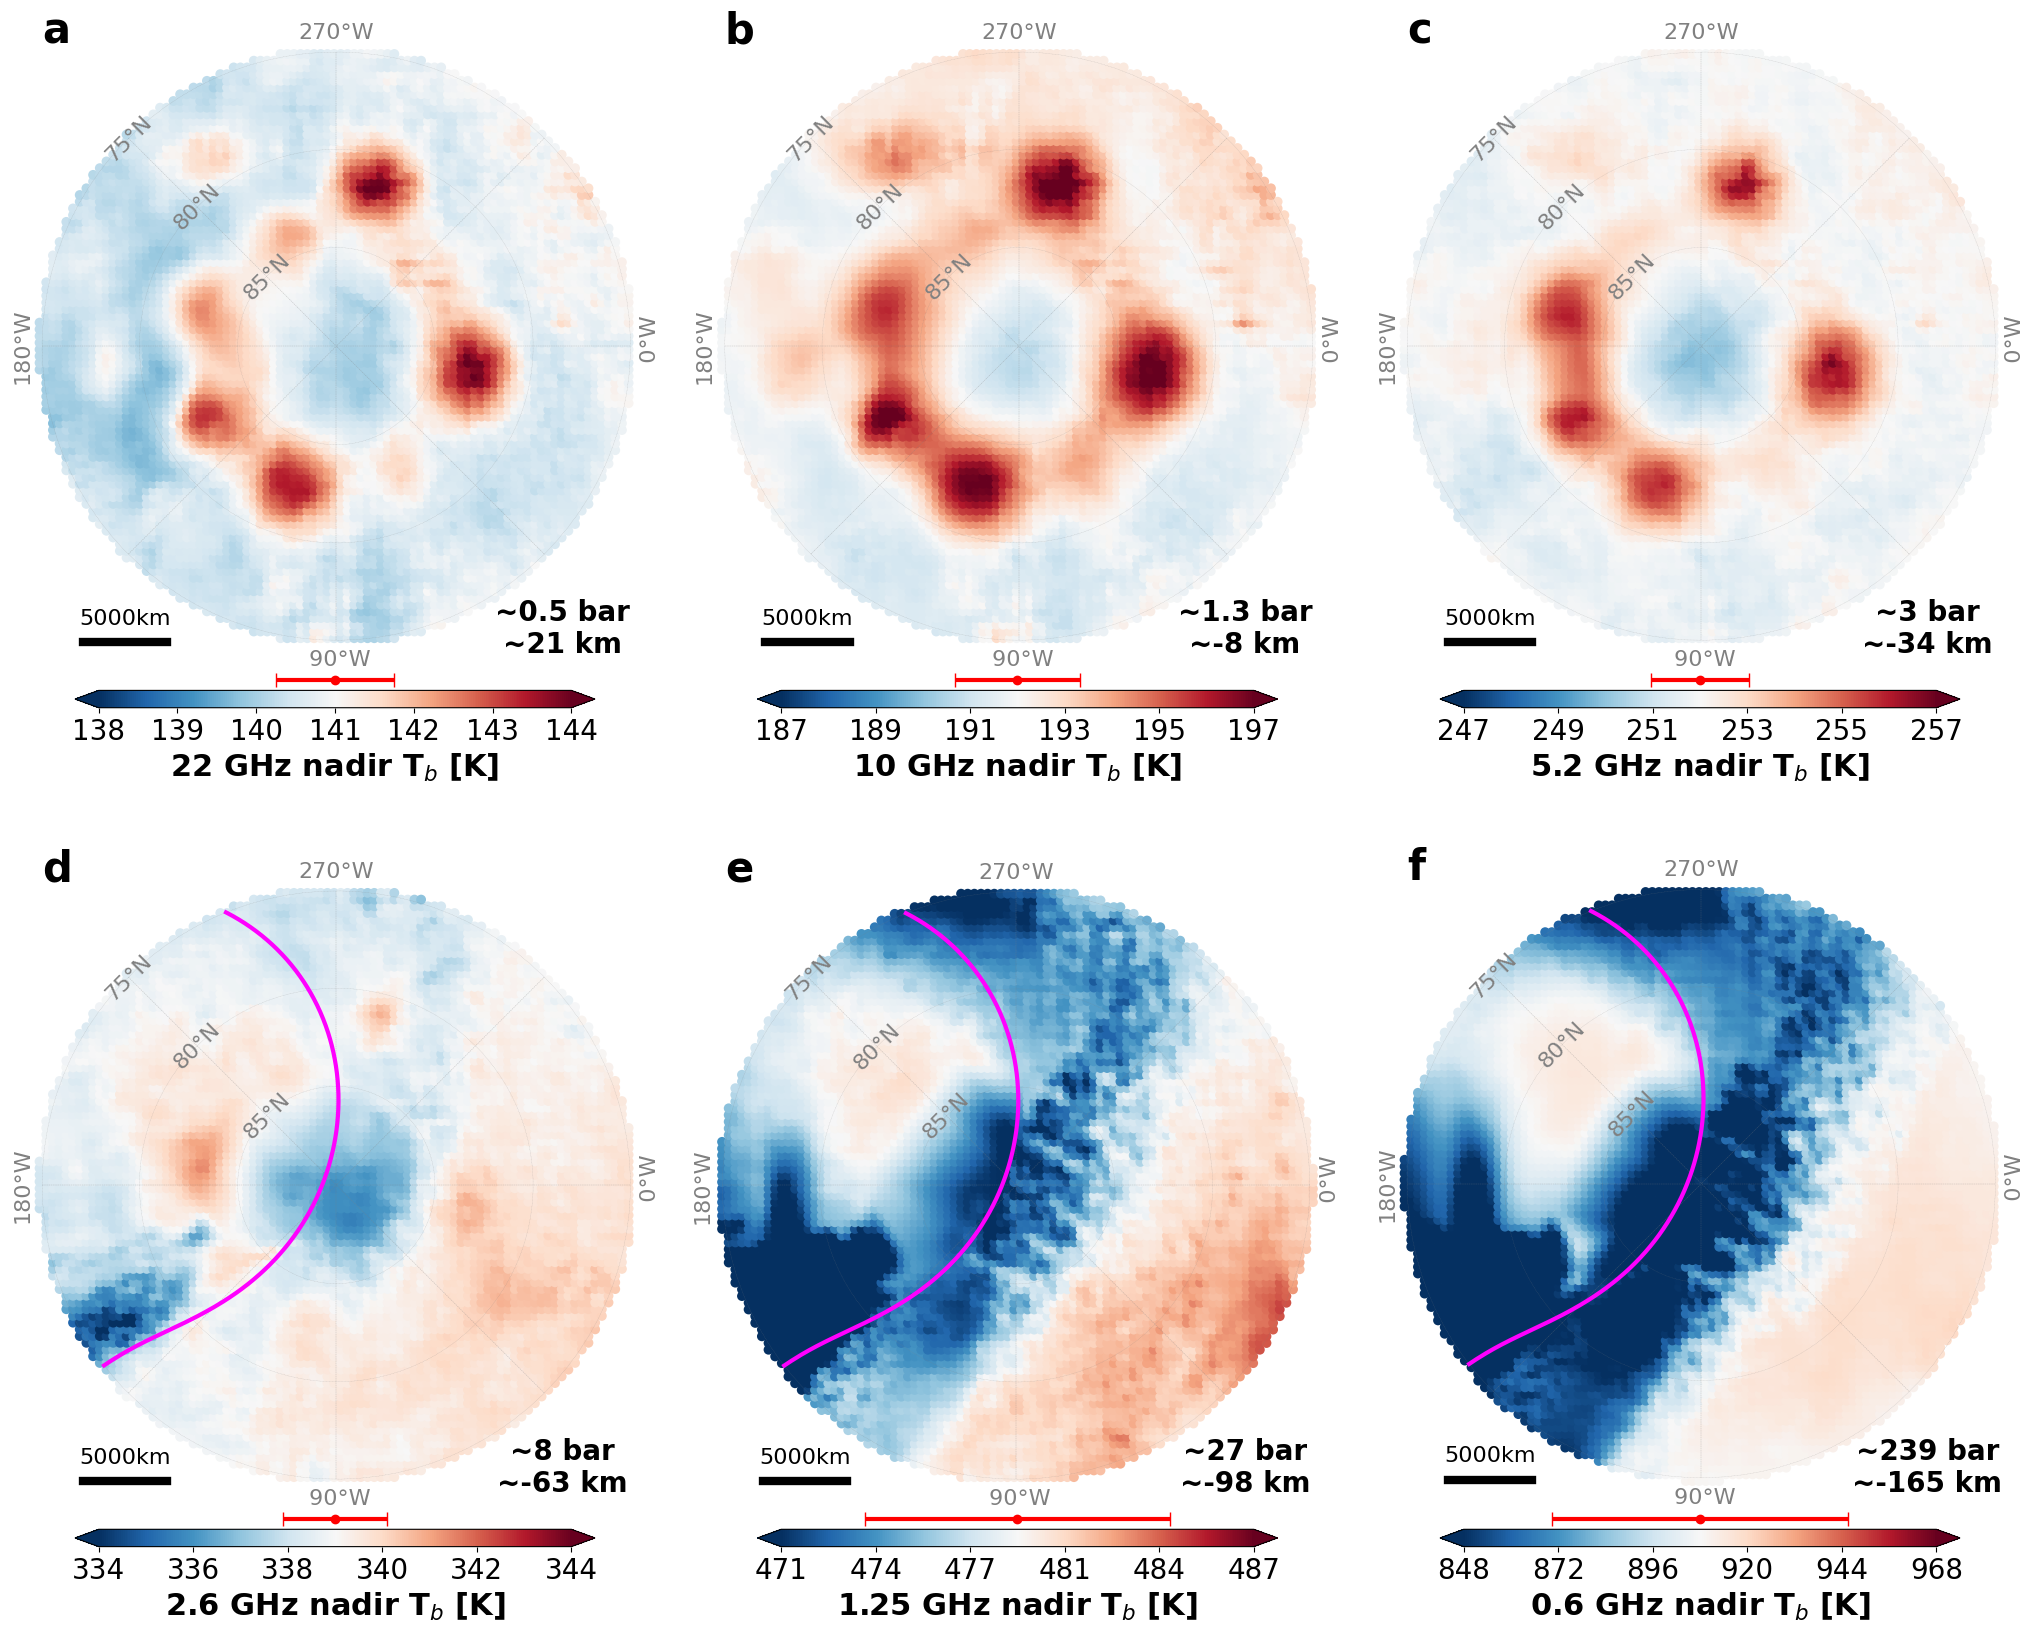

In [10]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath

from scipy.interpolate import griddata
from scipy import ndimage
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Polygon

# plt.style.use('dark_background')

def trans_coordiantes(lat, lon):
    # Jupiter's radii in km
    R_equator = 71492.0  # Equatorial radius
    R_polar = 66854.0    # Polar radius

    # Convert lat and lon to radians
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)

    # Calculate the radius for each latitude (ellipsoidal shape of Jupiter)
    R = R_equator * np.cos(lat_rad)**2 + R_polar * np.sin(lat_rad)**2

    # Compute Cartesian coordinates
    x = R * np.cos(lat_rad) * np.cos(lon_rad)
    y = R * np.cos(lat_rad) * np.sin(lon_rad)

    return x, y


def plot_tbest(ax, lon,  lat, tb, title,ch):


    x,y= trans_coordiantes(lat, lon)
    # Create a grid for contour plotting
    # X, Y = np.meshgrid(x, y)

    # Create a regular grid for interpolation
    grid_x, grid_y = np.meshgrid(
        np.linspace(x.min(), x.max(), 100),  # Grid resolution along X
        np.linspace(y.min(), y.max(), 100)  # Grid resolution along Y
    )

    # tb = gaussian_smoothing(x, y, tb, sigma=0.001)

    grid_tb = griddata((x, y), tb, (grid_x, grid_y), method='linear')
    grid_tb = gaussian_filter(grid_tb, sigma=0.7)


    distance_to_origin = np.sqrt(grid_x**2 + grid_y**2)
    x75,y75=trans_coordiantes(74.8, 0)
    dist75 = np.sqrt(x75**2 + y75**2)
    grid_tb[distance_to_origin > dist75] = np.nan     

    # contour = ax.contourf(grid_x, grid_y, grid_tb, levels=levels[ch], cmap='RdBu_r',extend='both',)
    # contour = ax.contourf(grid_x, grid_y, grid_tb, levels=np.linspace(levels[ch][0],levels[ch][-1],255), cmap='RdBu_r',extend='both',)


    from matplotlib.colors import BoundaryNorm
    from matplotlib.cm import get_cmap

    cmap = get_cmap('RdBu_r', 255)
    clevels=np.linspace(levels[ch][0],levels[ch][-1],255)
    norm = BoundaryNorm(clevels, ncolors=255, clip=True)
    contour = ax.scatter(grid_x, grid_y, c=grid_tb, cmap=cmap, norm=norm, s=50, edgecolor='none', zorder=2)

    ax.set_aspect('equal')


    # Add colorbar
    cbar = plt.colorbar(contour, ax=ax, orientation='horizontal', shrink=0.8, aspect=30, pad=0.02, extend='both')

    cbar.ax.tick_params(labelsize=20)
    cbar.ax.set_xticks(levels[ch][::2])

    cbar.set_label(f"{freqs[ch]} GHz nadir T$_b$ [K]", fontsize=22, fontweight='bold')
    cbar.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:1.0f}'))
    # disable minor ticks
    cbar.ax.tick_params(axis='x', which='minor', bottom=False, top=False, labelbottom=False)
    cbar.ax.errorbar(Tnad[ch],1.6, xerr=stddev[ch], fmt='o', color='r', elinewidth=3, capsize=5, zorder=1000, clip_on=False)

    for ll in [85,80,75]:
        lons=np.linspace(-180, 180, 100)
        lats=np.linspace(ll, ll, 100)
        xg,yg=trans_coordiantes(lats, lons)
        color='gray'
        # if ll==75: lw=1 ; linestyle="-"; color='k'
        # else: 
        lw=0.2; linestyle="--"
        ax.plot(xg,yg,linestyle=linestyle, color=color, lw=lw, alpha=0.5)
        
        x,y=trans_coordiantes(ll, 135)
        ax.text(x,y, f"{ll:2.0f}°N", color='gray', va='center', ha="center", rotation=45, fontsize=16)


    for oo in np.linspace(45,360,8):
        lons=np.linspace(oo, oo, 100)
        lats=np.linspace(75, 90, 100)
        xg,yg=trans_coordiantes(lats, lons)
        ax.plot(xg,yg,"--", color='gray', lw=0.3, alpha=0.5)
        if oo%90==0:
            xo,yo=trans_coordiantes(74.5, oo)
            ha="center"
            va='center'
            ra=0
            if oo==180 : 
                ha="right"; ra=90
            if oo==270 : va="top"
            if oo==90 : va="bottom"
            if oo==360 : 
                ha="left"; ra=90
            ax.text(xo,yo, f"{360-oo:3.0f}°W", color='gray',rotation=ra,  va=va, ha=ha, fontsize=16)

    # Add a scalebar for 5000 km and 10,000 km
    scalebar_x = -15000   # Adjust position (X-coordinate)
    scalebar_y = -17500  # Adjust position (Y-coordinate)
    scalebar_width = 4000  # Adjust the thickness of the scale bar

    # Scale bar for 5000 km
    ax.plot([scalebar_x, scalebar_x + 5000], [scalebar_y, scalebar_y], 
            color='black', lw=6, label='5000 km')
    ax.text(scalebar_x + 2500, scalebar_y + scalebar_width/2, '5000km', 
            ha='center', va='top', fontsize=16, color='black')


    ## mark CPCs
    # for j in range(len(cpcs_index)):
    #     lon_min, lon_max = cpcs_lon_min[j], cpcs_lon_max[j]
    #     lat_min, lat_max = cpcs_lat_min[j], cpcs_lat_max[j]
        
    #     lon_center = (lon_min + lon_max) / 2
    #     lat_center = (lat_min + lat_max) / 2
    #     x,y= np.float32(trans_coordiantes(lat_center, lon_center))
    #     ax.text(x, y, f"{j+1}", fontsize=25, color="k", horizontalalignment='center', verticalalignment='center')
    # ax.text(0, 0, "PC", fontsize=25, color="k", horizontalalignment='center',  verticalalignment='center')

    ## mark aurora oval for CH2 and CH1
    if ch<3:
        # Reading  (ovlon and ovlat)
        oval_path = "/data/jihenghu/juno-mwr-deconv-research/11.polarmap_filtered/Jup_Aurora_Oval_expanded.txt"
        data = np.loadtxt(oval_path)
        ovlon = 0-data[:, 0]  # First column
        ovlat = data[:, 1]  # Second column
        omsk=(ovlat>75)

        xov,yov=trans_coordiantes(ovlat[omsk], ovlon[omsk])
        ax.plot(xov,yov, color='magenta', lw=3, label='Aurora')

                # Reading  (ovlon and ovlat)
        oval_path = "/home/ananyo/mwr_ftpt/Oval/Jup_compressed.txt"
        data = np.loadtxt(oval_path)
        ovlon = 0-data[:, 0]  # First column
        ovlat = data[:, 1]  # Second column
        omsk=(ovlat>75)

        xov,yov=trans_coordiantes(ovlat[omsk], ovlon[omsk])
        # ax.plot(xov,yov, color='cyan', lw=3, label='Aurora')


    ax.text(0.05, 1.02, labels[5-ch], transform=ax.transAxes, fontsize=30, fontweight='bold', va='top', ha='left')
    ax.text(0.85, 0.02, f"~{[239,27,8,3,1.3,0.5][ch]} bar\n~{[-165,-98,-63,-34,-8,21][ch]} km", transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha='center')  
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])
    # ax.set_xlim([])
    return ax


labels = ['a', 'b', 'c', 'd','e','f']
freqs=[0.6,1.25,2.6,5.2,10,22]
levels=[np.linspace(-60, 60, 11)+Tnad[0],
        np.linspace(-8, 8, 11)+Tnad[1],
        np.linspace(-5, 5, 11)+Tnad[2],
        np.linspace(-5, 5, 11)+Tnad[3],
        np.linspace(-5, 5, 11)+Tnad[4],
        np.linspace(-3, 3, 13)+Tnad[5]]

cpcs_index = np.array([1, 2, 3, 4, 5, 6, 7, 8])
cpcs_lon_min = np.array([-30, -75, -130, -165, 155, 110, 60, 20])
cpcs_lon_max = np.array([10, -45, -90, -135, 180, 130, 90, 40])
cpcs_lat_min = np.array([80.5, 82, 80.5, 80.5, 80.5, 82.5, 79.5, 82.5])
cpcs_lat_max = np.array([85, 85, 85, 85, 85, 86, 84, 86])

fig, axs = plt.subplots(2,3, figsize=(26, 23),dpi=100, gridspec_kw={'hspace':-0.1, 'wspace':0.05},)
axes = axs.flatten()[[5,4,3,2,1,0]]


h5file=h5py.File("Tb_PJ51_PJ61_allchannels_FA02.h5", "r")
# h5file=h5py.File("Tb_PJ51_PJ61_allchannels_origin.h5", "r")
# h5file=h5py.File("/data/jihenghu/juno-mwr-deconv-research/7.pj57_pj61/Tb_nadir_northpole_PJ51_PJ61_allchn.h5", "r")

for ch in range(1,7):
    tb=h5file[f"ch{ch}"]["Tb"][:]
    lon=h5file[f"ch{ch}"]["lon"][:]
    lat=h5file[f"ch{ch}"]["lat"][:]
    ax=ch-1
    plot_tbest(axes[ax],lon,lat,tb, f"Channel {ch}", ax)

# plt.tight_layout()
# plt.show()
plt.savefig("nadir_tb_pattern.pdf", bbox_inches='tight', dpi=300)

# plt.savefig("nadir_tb_trans.png", bbox_inches='tight', transparent=True, dpi=300)

In [5]:
# make polar area-weighted mean Tb maps for each channel
import numpy as np
import h5py
from scipy.interpolate import griddata

def trans_latlon_to_xy(lat, lon):
    # Jupiter's radii in km
    R_equator = 71492.0  # Equatorial radius
    R_polar = 66854.0    # Polar radius

    # Convert lat and lon to radians
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)

    # Calculate the radius for each latitude (ellipsoidal shape of Jupiter)
    R = R_equator * np.cos(lat_rad)**2 + R_polar * np.sin(lat_rad)**2

    # Compute Cartesian coordinates
    x = R * np.cos(lat_rad) * np.cos(lon_rad)
    y = R * np.cos(lat_rad) * np.sin(lon_rad)

    return x, y


def sph_area_triangle(p1, p2, p3):
    """计算单位球面上由三点组成的球面三角形面积"""
    a = np.array(p1)
    b = np.array(p2)
    c = np.array(p3)
    N = np.dot(a, np.cross(b, c))
    D = 1 + np.dot(a, b) + np.dot(b, c) + np.dot(c, a)
    return 2 * np.arctan2(N, D)

def sph_to_xyz(lon, lat):
    lon, lat = np.deg2rad(lon), np.deg2rad(lat)
    return [np.cos(lat)*np.cos(lon), np.cos(lat)*np.sin(lon), np.sin(lat)]

from scipy.optimize import fsolve
def inverse(phi, rc):
    R_equator = 71492.0  # Equatorial radius
    R_polar = 66854.0    # Polar radius
    return (R_equator * np.cos(phi)**2 + R_polar * np.sin(phi)**2) * np.cos(phi) - rc

def quad_area(lonlat, R):
    # lonlat = [(lon1,lat1), (lon2,lat2), (lon3,lat3), (lon4,lat4)]
    xyz = [sph_to_xyz(lon, lat) for lon, lat in lonlat]
    E1 = sph_area_triangle(xyz[0], xyz[1], xyz[2])
    E2 = sph_area_triangle(xyz[0], xyz[2], xyz[3])
    return abs(E1 + E2) * R**2

R_jup = 66854.0       # Jupiter radius in km


def trans_xy_to_lonlat(x,y):
    """
    Convert Cartesian coordinates (x, y) to longitude and latitude.
    """
    lon = np.arctan2(y, x)  # Longitude
    rc= np.sqrt(x**2 + y**2)

    phi_guess = np.radians(30)
    
    phi_solution = fsolve(inverse, phi_guess, args=(rc,))
    # Convert to degrees
    lat = phi_solution[0]
    if lon >180:
        lon = 2 * np.pi-lon

    return np.degrees(lon), np.degrees(lat)

stddev=[]
h5file=h5py.File("Tb_PJ51_PJ61_allchannels_FA02.h5", "r")
for ch in range(1,7):
    tb=h5file[f"ch{ch}"]["Tb"][:]
    lon=h5file[f"ch{ch}"]["lon"][:]
    lat=h5file[f"ch{ch}"]["lat"][:]
    ax=ch-1

    x,y= trans_latlon_to_xy(lat, lon)
    # Create a grid for contour plotting
    # X, Y = np.meshgrid(x, y)

    # Create a regular grid for interpolation
    grid_x, grid_y = np.meshgrid(
        np.linspace(x.min(), x.max(), 100),  # Grid resolution along X
        np.linspace(y.min(), y.max(), 100)  # Grid resolution along Y
    )

    # tb = gaussian_smoothing(x, y, tb, sigma=0.001)

    grid_tb = griddata((x, y), tb, (grid_x, grid_y), method='linear')
    # grid_tb = gaussian_filter(grid_tb, sigma=0.7)

    grid_lonlat = np.array([trans_xy_to_lonlat(x, y) for x, y in zip(grid_x.flatten(), grid_y.flatten())])
    grid_lon = grid_lonlat[:, 0].reshape(grid_x.shape) # Reshape
    grid_lat = grid_lonlat[:, 1].reshape(grid_x.shape)  # Reshape


    distance_to_origin = np.sqrt(grid_x**2 + grid_y**2)
    x75,y75=trans_latlon_to_xy(74.8, 0)
    dist75 = np.sqrt(x75**2 + y75**2)
    grid_tb[distance_to_origin > dist75] = np.nan     

    ny, nx = grid_x.shape
    dA = np.zeros((ny, nx))
    for i in range(ny-1):
        for j in range(nx-1):

            lonlat = [(grid_lon[i,j], grid_lat[i,j]),
                    (grid_lon[i,j+1], grid_lat[i,j+1]),
                    (grid_lon[i+1,j+1], grid_lat[i+1,j+1]),
                    (grid_lon[i+1,j], grid_lat[i+1,j])]
            dA[i,j] = quad_area(lonlat, R_jup)

    dA[-1,:] = dA[-2,:]
    dA[:,-1] = dA[:,-2]
            # dlam = np.deg2rad(grid_lon[i,j+1]-grid_lon[i,j]) if j<nx-1 else np.deg2rad(grid_lon[i,nx-1]-grid_lon[i,nx-2])
            # dphi_sin = np.sin(np.deg2rad(grid_lat[i+1,j])) - np.sin(np.deg2rad(grid_lat[i,j]))
            # dA[i,j] = R_jup**2 * dlam * dphi_sin

    dA[dA<1E5]=np.nan  # Mask very small areas
    dA[distance_to_origin > dist75] = np.nan  # Mask areas outside 75°N

    mean_Tb = np.nansum(grid_tb * dA)/ np.nansum(dA)

    # compute the area-weighted standard deviation
    std_Tb = np.sqrt(np.nansum(((grid_tb - mean_Tb)**2) * dA)/ np.nansum(dA))
    print(f"Channel {ch} area-weighted Tb std. dev.: ± {std_Tb:.2f} K")
    stddev.append(std_Tb)

Channel 1 area-weighted Tb std. dev.: ± 37.57 K
Channel 2 area-weighted Tb std. dev.: ± 5.18 K
Channel 3 area-weighted Tb std. dev.: ± 1.11 K
Channel 4 area-weighted Tb std. dev.: ± 1.03 K
Channel 5 area-weighted Tb std. dev.: ± 1.33 K
Channel 6 area-weighted Tb std. dev.: ± 0.74 K
